<a href="https://colab.research.google.com/github/ibinijoon/Ibinijoon/blob/Ibinijoon/KNOC_Practice_K_means_260202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

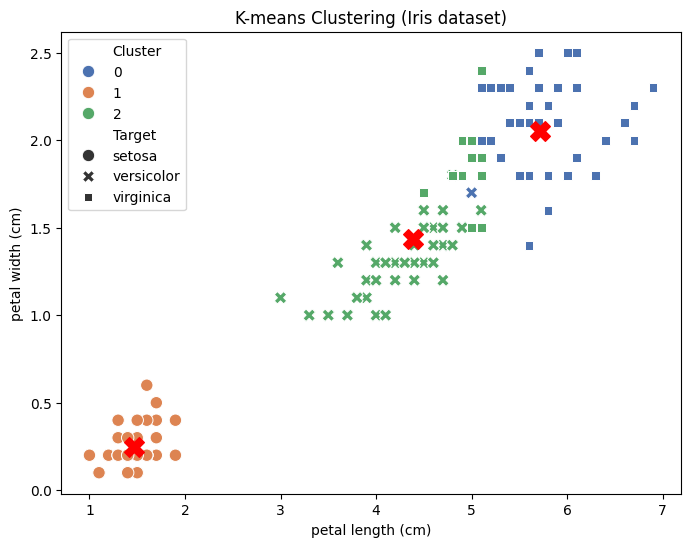

In [1]:
# 원본 데이터로 3개 군집 분류

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

# 데이터 불러오기
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# 특징(X)과 타겟(y) 분리
X = df.drop('species', axis=1)
y = df['species']

# K-means 모델 학습 (클러스터 3개)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# 클러스터 라벨
labels = kmeans.labels_

# 데이터프레임으로 변환 (시각화를 위해)
df = pd.DataFrame(X, columns=iris.feature_names)
df['Cluster'] = labels
df['Target'] = y

# 2D 시각화 (Petal length vs Petal width)
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['petal length (cm)'],
    y=df['petal width (cm)'],
    hue=df['Cluster'],
    palette="deep",
    style=df['Target'],  # 실제 species와 비교
    s=80
)

centers = kmeans.cluster_centers_  # shape: (3, 4)

# Petal length / width 기준으로 클러스터 중심 추출
centers_petal = centers[:, 2:4]  # 2: petal length, 3: petal width


# 클러스터 중심 표시
plt.scatter(
    centers_petal[:,0],  # Petal Length
    centers_petal[:,1],  # Petal Width
    c='red',
    s=200,
    marker='X'
)


plt.title("K-means Clustering (Iris dataset)")
plt.show()

In [3]:
import numpy as np
from sklearn.metrics import accuracy_score
from scipy.stats import mode



In [4]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster,Target
0,5.1,3.5,1.4,0.2,1,setosa
1,4.9,3.0,1.4,0.2,1,setosa
2,4.7,3.2,1.3,0.2,1,setosa
3,4.6,3.1,1.5,0.2,1,setosa
4,5.0,3.6,1.4,0.2,1,setosa


In [6]:
target_num = df['Target'].map({
    'setosa':0,
    'versicolor': 1,
    'virginica': 2
    }).values

In [8]:
target_num

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [9]:
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0,
       0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 2], dtype=int32)

In [11]:
mapped_labels = np.zeros_like(labels)

In [12]:
mapped_labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [13]:
mapped_labels = np.zeros_like(labels)
for i in range(3):
    mask = (labels == i)
    mapped_labels[mask] = mode(target_num[mask])[0]


In [16]:
accuracy = accuracy_score(target_num, mapped_labels)
print(f"K-means Clustering Accuracy: {accuracy:.4f}")

K-means Clustering Accuracy: 0.8867
